# FEDL Experiment Results

Quick review of evaluation outputs in `results/`.

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('.')
RESULTS = ROOT / 'results'
RESULTS

PosixPath('results')

In [3]:
# List result folders/files
sorted([p.name for p in RESULTS.iterdir()])

['all_eval',
 'b_0.1_edl.csv',
 'b_0.1_edl_hist.png',
 'b_0.1_g_1.0_fedl.csv',
 'b_0.1_g_1.0_fisher_hist.png',
 'best_eval',
 'edl_hist_by_beta',
 'fisher_hist_by_beta_gamma',
 'seed_sweep_eval',
 'wandb_summary.csv',
 'wandb_summary.md']

## Seed sweep eval (per-seed CSVs)

In [4]:
seed_dir = RESULTS / 'seed_sweep_eval'
edl_files = sorted([p for p in seed_dir.glob('edl_seed*.csv') if '_hist' not in p.name])
edl_files2 = sorted([p for p in seed_dir.glob('b_0.1_edl_seed*.csv') if '_hist' not in p.name])
edl_files3 = sorted([p for p in seed_dir.glob('b_0.01_edl_seed*.csv') if '_hist' not in p.name])
edl_files4 = sorted([p for p in seed_dir.glob('b_0.001_edl_seed*.csv') if '_hist' not in p.name])
fisher_files = sorted([p for p in seed_dir.glob('fisher_seed*.csv') if '_hist' not in p.name])
len(edl_files), len(edl_files2), len(edl_files4), len(fisher_files)

(5, 5, 5, 5)

In [5]:
def load_csvs(files):
    dfs = [pd.read_csv(f) for f in files]
    return pd.concat(dfs, ignore_index=True)

edl_df = load_csvs(edl_files)
edl_df2 = load_csvs(edl_files2)
edl_df3 = load_csvs(edl_files3)
edl_df4 = load_csvs(edl_files4)
fisher_df = load_csvs(fisher_files)
edl_df

,ckpt,test_acc,test_uncertainty,svhn_uncertainty,cifar100_uncertainty,svhn_auroc_test,cifar100_auroc_test,svhn_fpr95_test,cifar100_fpr95_test
0,runs/seed_sweep/edl_seed1/best_val_acc.pt,0.9234,0.985979,0.985691,0.986602,0.533833,0.639144,0.9998,0.9901
1,runs/seed_sweep/edl_seed2/best_val_acc.pt,0.9218,0.985876,0.985683,0.986034,0.462411,0.514109,0.9957,0.9924
2,runs/seed_sweep/edl_seed3/best_val_acc.pt,0.9197,0.985692,0.984619,0.986286,0.259798,0.606975,0.9988,0.9928
3,runs/seed_sweep/edl_seed4/best_val_acc.pt,0.9178,0.986121,0.985935,0.986598,0.394971,0.574103,0.9952,0.9896
4,runs/seed_sweep/edl_seed5/best_val_acc.pt,0.9197,0.985660,0.985055,0.985990,0.385202,0.545506,0.9989,0.9944


In [6]:
metrics = [c for c in edl_df.columns if c != 'ckpt']
edl_summary = edl_df[metrics].agg(['mean', 'std'])
edl_summary2 = edl_df2[metrics].agg(['mean', 'std'])
edl_summary3 = edl_df3[metrics].agg(['mean', 'std'])
edl_summary4 = edl_df4[metrics].agg(['mean', 'std'])
fisher_summary = fisher_df[metrics].agg(['mean', 'std'])

# EDL(beta=1)

In [7]:
edl_summary

,test_acc,test_uncertainty,svhn_uncertainty,cifar100_uncertainty,svhn_auroc_test,cifar100_auroc_test,svhn_fpr95_test,cifar100_fpr95_test
mean,0.92048,0.985866,0.985397,0.986302,0.407243,0.575967,0.99768,0.991860
std,0.00216,0.000194,0.000543,0.000295,0.101790,0.049271,0.00208,0.001989


# EDL(beta=0.1)

In [8]:
edl_summary2

,test_acc,test_uncertainty,svhn_uncertainty,cifar100_uncertainty,svhn_auroc_test,cifar100_auroc_test,svhn_fpr95_test,cifar100_fpr95_test
mean,0.91526,0.669695,0.735256,0.727204,0.826330,0.752653,0.665340,0.898980
std,0.00275,0.002499,0.014528,0.006239,0.066737,0.018234,0.156624,0.044757


# EDL(beta=0.01)

In [9]:
edl_summary3

,test_acc,test_uncertainty,svhn_uncertainty,cifar100_uncertainty,svhn_auroc_test,cifar100_auroc_test,svhn_fpr95_test,cifar100_fpr95_test
mean,0.916000,0.220821,0.291994,0.296480,0.799265,0.773443,0.643200,0.886340
std,0.002897,0.002324,0.031046,0.013822,0.113190,0.013497,0.317098,0.031251


# EDL(beta=0.001)

In [10]:
edl_summary4

,test_acc,test_uncertainty,svhn_uncertainty,cifar100_uncertainty,svhn_auroc_test,cifar100_auroc_test,svhn_fpr95_test,cifar100_fpr95_test
mean,0.916200,0.073154,0.165951,0.139189,0.915563,0.832052,0.291180,0.667500
std,0.002355,0.000881,0.050117,0.006822,0.022522,0.010684,0.079603,0.047548


# Info-EDL(beta=1)

In [11]:
fisher_summary

,test_acc,test_uncertainty,svhn_uncertainty,cifar100_uncertainty,svhn_auroc_test,cifar100_auroc_test,svhn_fpr95_test,cifar100_fpr95_test
mean,0.914980,0.023356,0.074437,0.066610,0.939122,0.873503,0.187580,0.418960
std,0.001835,0.001050,0.011703,0.001711,0.014293,0.001344,0.033171,0.010557


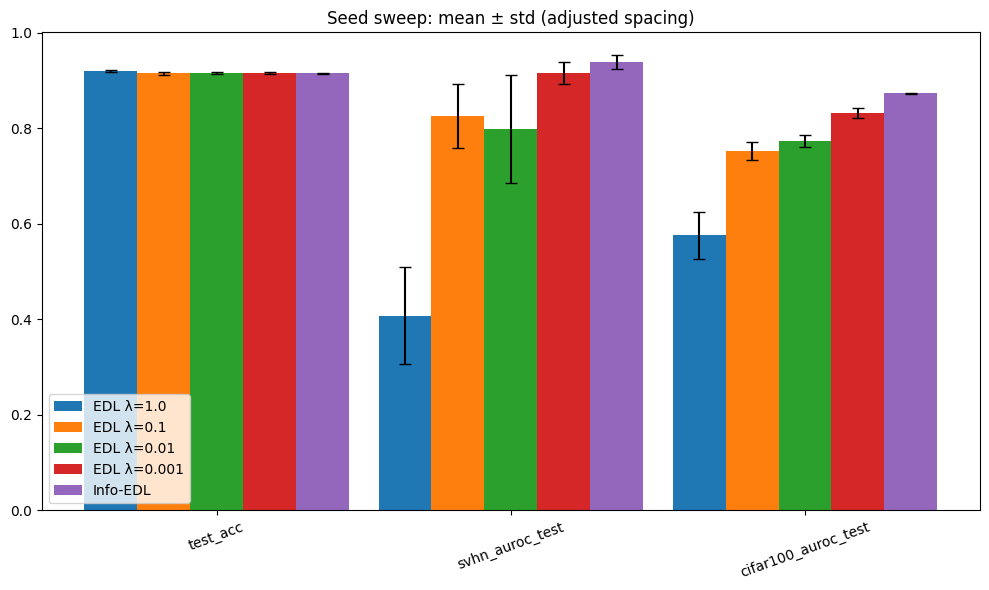

In [13]:
# Bar chart: mean ± std for selected metrics with adjusted spacing
plot_metrics = ['test_acc', 'svhn_auroc_test', 'cifar100_auroc_test']
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(plot_metrics))
width = 0.18

models = [
       (edl_summary, 'EDL λ=1.0'),
       (edl_summary2, 'EDL λ=0.1'),
       (edl_summary3, 'EDL λ=0.01'),
       (edl_summary4, 'EDL λ=0.001'),
       (fisher_summary, 'Info-EDL'),
]
n = len(models)
offsets = [(i - (n - 1) / 2) * width for i in range(n)]

for off, (df, label) in zip(offsets, models):
       ax.bar([i + off for i in x],
                 df.loc['mean', plot_metrics],
                 yerr=df.loc['std', plot_metrics],
                 width=width, label=label, capsize=4)

ax.set_xticks(list(x))
ax.set_xticklabels(plot_metrics, rotation=20)
ax.set_title('Seed sweep: mean ± std (adjusted spacing)')
ax.legend()
plt.tight_layout()
plt.show()

## Histogram results (CSV and PNG)

In [20]:
edl_hist_dir = RESULTS / 'seed_sweep_eval'
fisher_hist_dir = RESULTS / 'seed_sweep_eval'
edl_hist_csvs = sorted([p for p in edl_hist_dir.glob('*_hist.csv')])
fisher_hist_csvs = sorted([p for p in fisher_hist_dir.glob('*_hist.csv')])
edl_hist_pngs = sorted([p for p in edl_hist_dir.glob('*_hist.png')])
fisher_hist_pngs = sorted([p for p in fisher_hist_dir.glob('*_hist.png')])
edl_hist_csvs[:5], fisher_hist_csvs[:5]

([PosixPath('results/seed_sweep_eval/edl_seed1_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed2_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed3_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed4_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed5_hist.csv')],
 [PosixPath('results/seed_sweep_eval/edl_seed1_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed2_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed3_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed4_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed5_hist.csv')])

In [21]:
# List histogram CSVs (ID vs OOD uncertainty bins)
edl_hist_csvs[:5], fisher_hist_csvs[:5]

([PosixPath('results/seed_sweep_eval/edl_seed1_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed2_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed3_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed4_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed5_hist.csv')],
 [PosixPath('results/seed_sweep_eval/edl_seed1_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed2_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed3_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed4_hist.csv'),
  PosixPath('results/seed_sweep_eval/edl_seed5_hist.csv')])

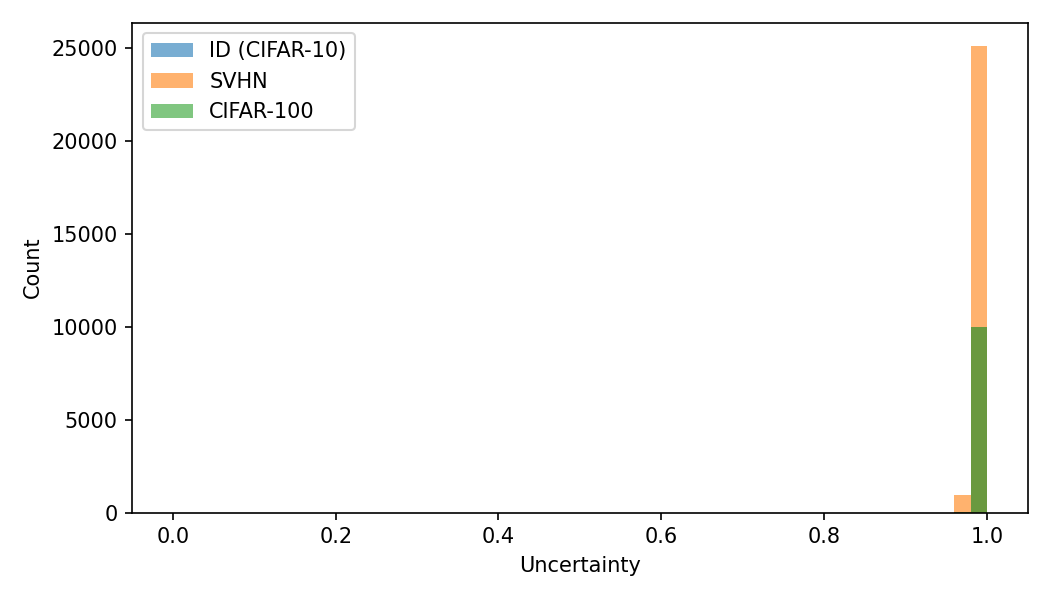

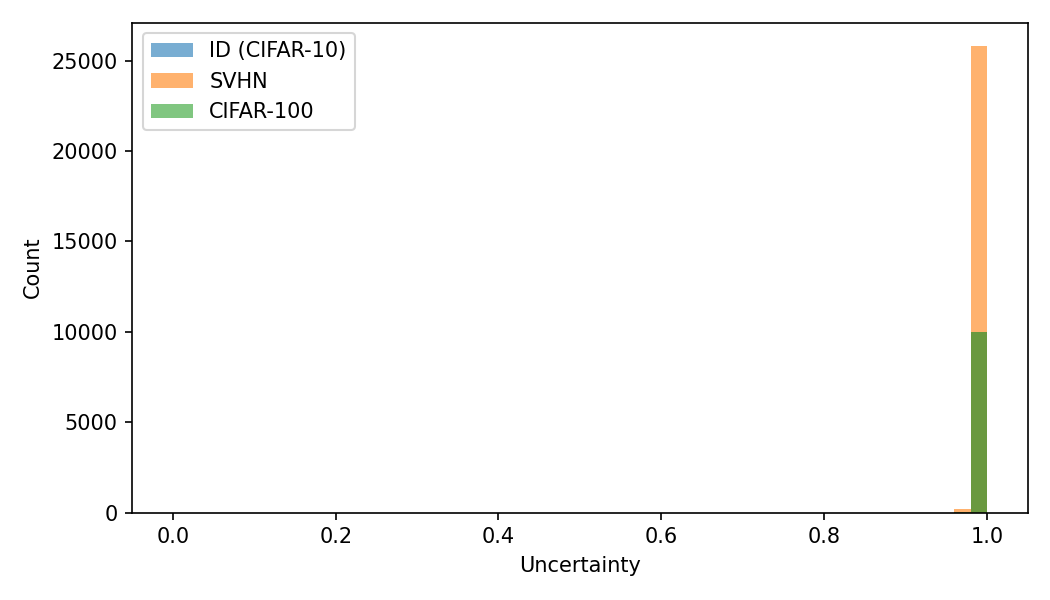

In [22]:
# Display a couple of histogram images
from IPython.display import Image, display

for img in edl_hist_pngs[:2]:
    display(Image(filename=str(img)))